<a href="https://colab.research.google.com/github/1WA23CS034/Machine-Learning/blob/main/ML_lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

lab 6 - KNN

In [4]:
import pandas as pd
df1=pd.read_csv("iris.csv")
df1

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [5]:
df2=pd.read_csv("diabetes.csv")
df2

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [6]:
df3=pd.read_csv("heart.csv")
df3

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


### KNN Classifier for Iris Dataset (df1)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

X_iris = df1.drop('species', axis=1)
y_iris = df1['species']

# Split data into training and testing sets (80% train, 20% test)
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

print("Iris Dataset Split:")
print(f"Training features shape: {X_train_iris.shape}")
print(f"Testing features shape: {X_test_iris.shape}")
print(f"Training target shape: {y_train_iris.shape}")
print(f"Testing target shape: {y_test_iris.shape}")

Iris Dataset Split:
Training features shape: (120, 4)
Testing features shape: (30, 4)
Training target shape: (120,)
Testing target shape: (30,)


#### Choosing an appropriate `k` value for Iris Dataset

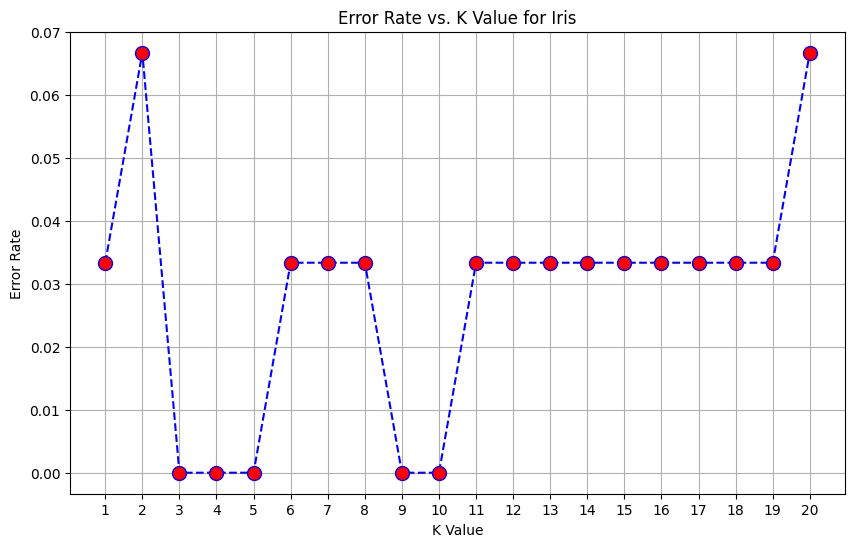

Chosen K value for Iris: 5


In [8]:
error_rate_iris = []

for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_iris, y_train_iris)
    pred_i = knn.predict(X_test_iris)
    error_rate_iris.append(np.mean(pred_i != y_test_iris))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), error_rate_iris, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value for Iris')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(np.arange(1, 21, 1))
plt.grid(True)
plt.show()


k_iris = 5
print(f"Chosen K value for Iris: {k_iris}")

#### Building and Evaluating KNN Model for Iris

In [9]:
knn_iris = KNeighborsClassifier(n_neighbors=k_iris)

knn_iris.fit(X_train_iris, y_train_iris)

y_pred_iris = knn_iris.predict(X_test_iris)

accuracy_iris = accuracy_score(y_test_iris, y_pred_iris)
print(f"Accuracy Score for Iris KNN: {accuracy_iris:.4f}")

conf_matrix_iris = confusion_matrix(y_test_iris, y_pred_iris)
print("\nConfusion Matrix for Iris:\n")
display(conf_matrix_iris)

class_report_iris = classification_report(y_test_iris, y_pred_iris)
print("\nClassification Report for Iris:\n")
print(class_report_iris)

Accuracy Score for Iris KNN: 1.0000

Confusion Matrix for Iris:



array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  0, 10]])


Classification Report for Iris:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### KNN Classifier for Diabetes Dataset (df2)

In [11]:
from sklearn.preprocessing import StandardScaler

X_diabetes = df2.drop('Outcome', axis=1)
y_diabetes = df2['Outcome']

# Split data into training and testing sets (80% train, 20% test)
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42, stratify=y_diabetes
)

print("Diabetes Dataset Split:")
print(f"Training features shape: {X_train_diabetes.shape}")
print(f"Testing features shape: {X_test_diabetes.shape}")
print(f"Training target shape: {y_train_diabetes.shape}")
print(f"Testing target shape: {y_test_diabetes.shape}")

Diabetes Dataset Split:
Training features shape: (614, 8)
Testing features shape: (154, 8)
Training target shape: (614,)
Testing target shape: (154,)


#### Feature Scaling for Diabetes Dataset

In [12]:
scaler = StandardScaler()

X_train_scaled_diabetes = scaler.fit_transform(X_train_diabetes)
X_test_scaled_diabetes = scaler.transform(X_test_diabetes)

print("Features scaled for Diabetes dataset.")
print("First 5 rows of scaled training data:")
display(pd.DataFrame(X_train_scaled_diabetes, columns=X_diabetes.columns).head())

Features scaled for Diabetes dataset.
First 5 rows of scaled training data:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.851355,-0.980131,-0.404784,-0.553973,-0.331319,-0.607678,0.310794,-0.792169
1,0.356576,0.161444,0.465368,0.392787,-0.526398,-0.302139,-0.116439,0.561034
2,-0.549372,-0.504474,-0.622322,1.213312,0.142444,0.372594,-0.764862,-0.707594
3,-0.851355,0.795653,-0.731091,-1.311380,-0.730766,-0.289408,0.262314,-0.369293
4,-1.153338,-0.821579,-0.296015,1.150195,0.244628,1.607482,-0.337630,-0.961320


#### Choosing an appropriate `k` value for Diabetes Dataset

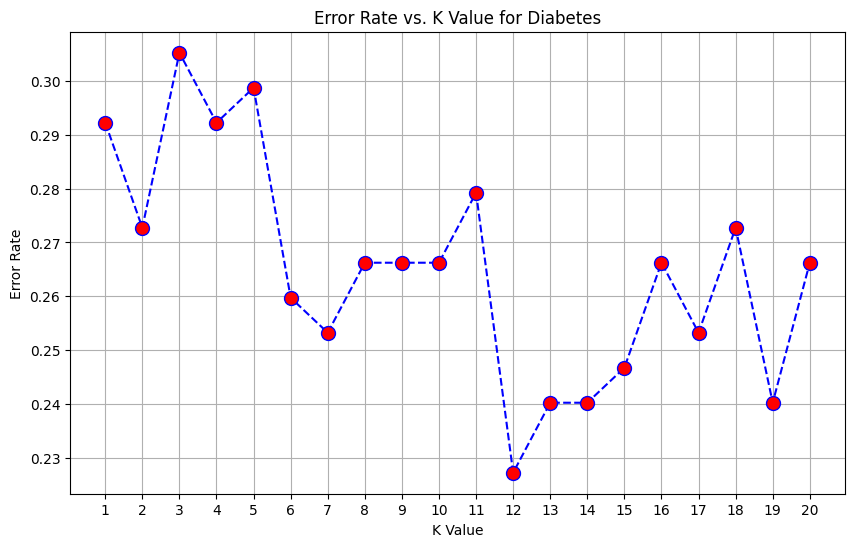

Chosen K value for Diabetes: 11


In [13]:
error_rate_diabetes = []

for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled_diabetes, y_train_diabetes)
    pred_i = knn.predict(X_test_scaled_diabetes)
    error_rate_diabetes.append(np.mean(pred_i != y_test_diabetes))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), error_rate_diabetes, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value for Diabetes')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(np.arange(1, 21, 1))
plt.grid(True)
plt.show()

k_diabetes = 11
print(f"Chosen K value for Diabetes: {k_diabetes}")

#### Building and Evaluating KNN Model for Diabetes

In [14]:
knn_diabetes = KNeighborsClassifier(n_neighbors=k_diabetes)

knn_diabetes.fit(X_train_scaled_diabetes, y_train_diabetes)

y_pred_diabetes = knn_diabetes.predict(X_test_scaled_diabetes)

accuracy_diabetes = accuracy_score(y_test_diabetes, y_pred_diabetes)
print(f"Accuracy Score for Diabetes KNN: {accuracy_diabetes:.4f}")

conf_matrix_diabetes = confusion_matrix(y_test_diabetes, y_pred_diabetes)
print("\nConfusion Matrix for Diabetes:\n")
display(conf_matrix_diabetes)

class_report_diabetes = classification_report(y_test_diabetes, y_pred_diabetes)
print("\nClassification Report for Diabetes:\n")
print(class_report_diabetes)

Accuracy Score for Diabetes KNN: 0.7208

Confusion Matrix for Diabetes:



array([[80, 20],
       [23, 31]])


Classification Report for Diabetes:

              precision    recall  f1-score   support

           0       0.78      0.80      0.79       100
           1       0.61      0.57      0.59        54

    accuracy                           0.72       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.72      0.72       154



Iris Dataset (df1):
Data Split: 80% for training (120 samples), 20% for testing (30 samples).
Chosen K Value: Based on the error rate plot, k=5 was selected as an optimal value.
Model Performance:
Accuracy Score: 1.0000 (100% accuracy).
Confusion Matrix:
[[10, 0, 0],
 [ 0, 10, 0],
 [ 0, 0, 10]]
This shows that all 10 samples of 'setosa', 10 samples of 'versicolor', and 10 samples of 'virginica' were correctly classified.
Classification Report: All precision, recall, and f1-scores are 1.00 for all classes, indicating a perfect classification.
Diabetes Dataset (df2):
Data Split: 80% for training (614 samples), 20% for testing (154 samples).
Feature Scaling: StandardScaler was applied to normalize the features, which is crucial for distance-based algorithms like KNN.
Chosen K Value: Based on the error rate plot, k=11 was selected.
Model Performance:
Accuracy Score: 0.7208 (approximately 72.08% accuracy).
Confusion Matrix:
[[80, 20],
 [23, 31]]
Out of 100 actual 'No Diabetes' cases, 80 were correctly predicted, and 20 were misclassified as 'Diabetes'.
Out of 54 actual 'Diabetes' cases, 31 were correctly predicted, and 23 were misclassified as 'No Diabetes'.
Classification Report:
Class 0 (No Diabetes): Precision 0.78, Recall 0.80, F1-score 0.79.
Class 1 (Diabetes): Precision 0.61, Recall 0.57, F1-score 0.59. The model performs better at identifying individuals without diabetes (Class 0) compared to those with diabetes (Class 1), as indicated by the higher precision and recall for Class 0.
Overall, the KNN model performed exceptionally well on the Iris dataset, achieving 100% accuracy, while the diabetes dataset showed a reasonable performance with about 72% accuracy after feature scaling.

### KNN Classifier for Heart Disease Dataset (df3)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

X_heart = df3.drop('target', axis=1)
y_heart = df3['target']

# Split data into training and testing sets (80% train, 20% test)
X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart
)

print("Heart Disease Dataset Split:")
print(f"Training features shape: {X_train_heart.shape}")
print(f"Testing features shape: {X_test_heart.shape}")
print(f"Training target shape: {y_train_heart.shape}")
print(f"Testing target shape: {y_test_heart.shape}")

Heart Disease Dataset Split:
Training features shape: (242, 13)
Testing features shape: (61, 13)
Training target shape: (242,)
Testing target shape: (61,)


#### Feature Scaling for Heart Disease Dataset

In [16]:
scaler_heart = StandardScaler()
X_train_scaled_heart = scaler_heart.fit_transform(X_train_heart)
X_test_scaled_heart = scaler_heart.transform(X_test_heart)

print("Features scaled for Heart Disease dataset.")
print("First 5 rows of scaled training data:")
display(pd.DataFrame(X_train_scaled_heart, columns=X_heart.columns).head())

Features scaled for Heart Disease dataset.
First 5 rows of scaled training data:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,1.610480,-1.46385,2.044420,0.461840,-0.123235,-0.404304,0.857493,0.039942,-0.715891,0.604853,0.948185,1.207034,-0.561223
1,1.282051,0.68313,0.057474,1.575595,0.023366,-0.404304,0.857493,-1.373486,1.396861,-0.890458,-0.667736,2.167896,-2.217514
2,0.077810,-1.46385,-0.936000,-0.206413,-0.835301,-0.404304,2.743977,-0.917541,1.396861,0.770998,-0.667736,0.246171,1.095069
3,0.296763,0.68313,-0.936000,-1.208792,1.887302,-0.404304,0.857493,-0.324813,1.396861,1.601727,-0.667736,0.246171,1.095069
4,1.829433,-1.46385,1.050947,-1.208792,0.421285,2.473388,-1.028992,-0.917541,-0.715891,-0.890458,0.948185,0.246171,-0.561223


#### Choosing an appropriate `k` value for Heart Disease Dataset

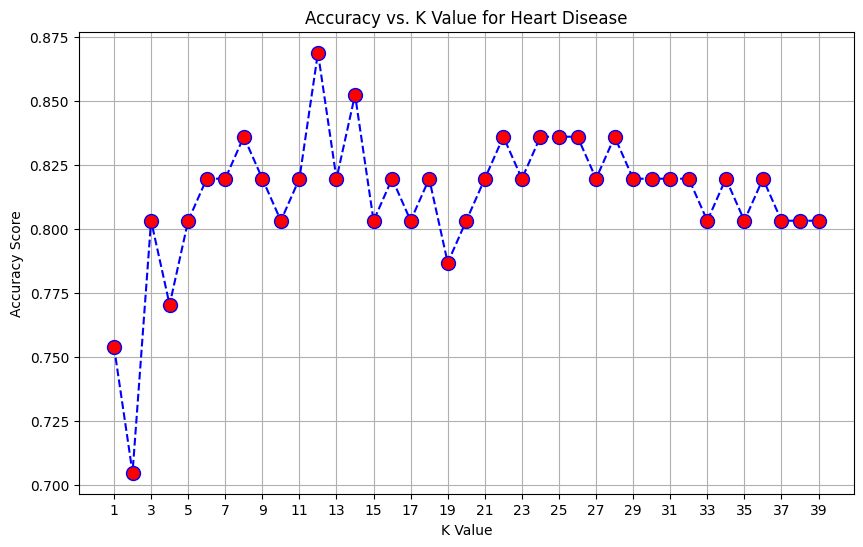

Optimal K value for Heart Disease: 12
Maximum Accuracy for Heart Disease at optimal K: 0.8689


In [17]:
accuracy_scores_heart = []
k_values = range(1, 40)

for i in k_values:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled_heart, y_train_heart)
    y_pred_heart_k = knn.predict(X_test_scaled_heart)
    accuracy_scores_heart.append(accuracy_score(y_test_heart, y_pred_heart_k))

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_scores_heart, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Accuracy vs. K Value for Heart Disease')
plt.xlabel('K Value')
plt.ylabel('Accuracy Score')
plt.xticks(np.arange(1, 40, 2))
plt.grid(True)
plt.show()

optimal_k_heart = k_values[np.argmax(accuracy_scores_heart)]
max_accuracy_heart = np.max(accuracy_scores_heart)

print(f"Optimal K value for Heart Disease: {optimal_k_heart}")
print(f"Maximum Accuracy for Heart Disease at optimal K: {max_accuracy_heart:.4f}")

k_heart = optimal_k_heart

#### Building and Evaluating KNN Model for Heart Disease

In [19]:
knn_heart = KNeighborsClassifier(n_neighbors=k_heart)

knn_heart.fit(X_train_scaled_heart, y_train_heart)

y_pred_heart = knn_heart.predict(X_test_scaled_heart)

accuracy_heart = accuracy_score(y_test_heart, y_pred_heart)
print(f"Accuracy Score for Heart Disease KNN: {accuracy_heart:.4f}")

conf_matrix_heart = confusion_matrix(y_test_heart, y_pred_heart)
print("\nConfusion Matrix for Heart Disease:\n")
display(conf_matrix_heart)

class_report_heart = classification_report(y_test_heart, y_pred_heart)
print("\nClassification Report for Heart Disease:\n")
print(class_report_heart)

Accuracy Score for Heart Disease KNN: 0.8689

Confusion Matrix for Heart Disease:



array([[22,  6],
       [ 2, 31]])


Classification Report for Heart Disease:

              precision    recall  f1-score   support

           0       0.92      0.79      0.85        28
           1       0.84      0.94      0.89        33

    accuracy                           0.87        61
   macro avg       0.88      0.86      0.87        61
weighted avg       0.87      0.87      0.87        61



Heart Disease Dataset (df3):
Data Split: 80% for training (242 samples), 20% for testing (61 samples).
Feature Scaling: StandardScaler was applied to normalize the features, which is essential for KNN's distance-based calculations.
Chosen Optimal K Value: By iterating through k values from 1 to 39, the optimal k value that yielded the highest accuracy was found to be 12.
Model Performance:
Accuracy Score: 0.8689 (approximately 86.89% accuracy).
Confusion Matrix:
[[22,  6],
 [ 2, 31]]
Out of 28 actual 'No Disease' cases (target 0), 22 were correctly predicted, and 6 were misclassified as 'Disease'.
Out of 33 actual 'Disease' cases (target 1), 31 were correctly predicted, and 2 were misclassified as 'No Disease'.
Classification Report:
Class 0 (No Disease): Precision 0.92, Recall 0.79, F1-score 0.85.
Class 1 (Disease): Precision 0.84, Recall 0.94, F1-score 0.89. The model shows strong performance, particularly in identifying individuals with heart disease (Class 1), with a high recall score. The precision for Class 0 is also notably high.
Overall, the KNN model achieved a good accuracy of nearly 87% on the Heart Disease dataset after appropriate feature scaling and selection of an optimal k value.